In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/Project_NN/Data/Cleaned.csv")

df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,no_rooms,sqm,yield_on_mortgage_credit_bonds%,price_usd_log,house_age,year,quarter_num,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,...,sales_type_family_sale,sales_type_other_sale,sales_type_regular_sale,"area_Capital, Copenhagen",area_East & mid jutland,area_Fyn & islands,area_North Zealand,area_North jutland,area_Other islands,area_South jutland
0,3.0,74.0,4.34,12.822611,5.0,2024,3,False,False,False,...,False,False,True,True,False,False,False,False,False,False
1,2.0,39.0,4.34,12.031725,125.0,2024,3,False,False,False,...,False,False,True,False,False,False,False,True,False,False
2,3.0,116.0,4.34,11.596816,104.0,2024,3,False,False,False,...,False,False,True,False,False,False,False,False,False,True
3,4.0,127.0,4.34,12.307053,31.0,2024,3,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,5.0,160.0,4.34,12.492195,175.0,2024,3,False,False,False,...,False,False,True,False,False,False,True,False,False,False


In [ ]:
X = df.drop(columns=["price_usd_log"])
y = df["price_usd_log"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1)
])


model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=1
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - loss: 2.9385 - mae: 3.3291 - val_loss: 0.1721 - val_mae: 0.4613 - learning_rate: 0.0010
Epoch 2/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 0.1944 - mae: 0.5003 - val_loss: 0.1667 - val_mae: 0.4570 - learning_rate: 0.0010
Epoch 3/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.1775 - mae: 0.4744 - val_loss: 0.1605 - val_mae: 0.4455 - learning_rate: 0.0010
Epoch 4/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1696 - mae: 0.4614 - val_loss: 0.1491 - val_mae: 0.4244 - learning_rate: 0.0010
Epoch 5/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1647 - mae: 0.4530 - val_loss: 0.1473 - val_mae: 0.4205 - learning_rate: 0.0010
Epoch 6/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.1616 - mae: 0.4481 - val_loss: 0.1451 - val_mae: 0.4183 - learning_rate: 0.0010
Epoch 7/200
987/987 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.1593 - mae: 0.4435 - val_loss: 0.1447 - val_mae: 0.4185 - learning_rate: 0.

In [ ]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Huber Loss: {test_loss:.5f}")
print(f"Test MAE: {test_mae:.5f}")

Test Huber Loss: 0.12612
Test MAE: 0.38162


In [ ]:
preds = model(X_test).numpy()
y_true = np.array(y_test)

mse = mean_squared_error(y_true, preds)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, preds)
r2 = r2_score(y_true, preds)

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

MSE: 0.26199060576690525
RMSE: 0.5118501790240043
MAE: 0.38161929698722
R2: 0.5658413172482994


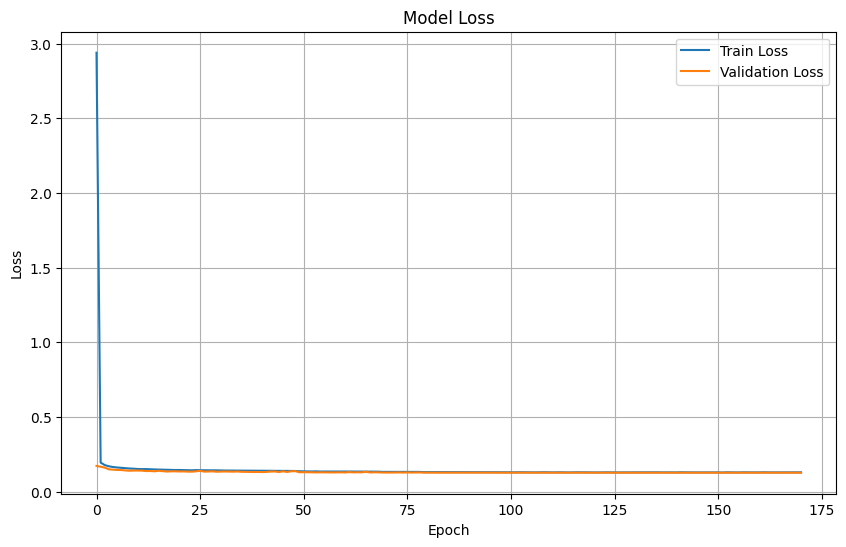

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.layers import LeakyReLU
from sklearn.metrics import mean_squared_error, mean_absolute_error
import pandas as pd

results = []

# Experiment 1 >> ReLU + LR = 0.001

model1 = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),

    Dense(1)
])

model1.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='huber',
    metrics=['mae']
)

model1.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=0
)

preds1 = model1.predict(X_test, verbose=0)

mse1 = mean_squared_error(y_test, preds1)
mae1 = mean_absolute_error(y_test, preds1)
loss1 = model1.evaluate(X_test, y_test, verbose=0)[0]

results.append([
    "Exp 1",
    "ReLU",
    0.001,
    round(mse1,4),
    round(mae1,4),
    round(loss1,4)
])

# Experiment 2 >> LeakyReLU + LR = 0.0005

model2 = Sequential([
    Dense(256, input_shape=(X_train.shape[1],)),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32),
    LeakyReLU(negative_slope=0.1),
    BatchNormalization(),

    Dense(1)
])

model2.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='huber',
    metrics=['mae']
)

model2.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    verbose=0
)

preds2 = model2.predict(X_test, verbose=0)

mse2 = mean_squared_error(y_test, preds2)
mae2 = mean_absolute_error(y_test, preds2)
loss2 = model2.evaluate(X_test, y_test, verbose=0)[0]

results.append([
    "Exp 2",
    "LeakyReLU",
    0.0005,
    round(mse2,4),
    round(mae2,4),
    round(loss2,4)
])

results_df = pd.DataFrame(
    results,
    columns=["Experiment", "Activation", "LR", "MSE", "MAE", "Loss"]
)

print(results_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Experiment Activation      LR     MSE     MAE    Loss
0      Exp 1       ReLU  0.0010  0.2798  0.4003  0.1348
1      Exp 2  LeakyReLU  0.0005  0.2797  0.3983  0.1344


In [ ]:
nn_results = []
nn_results.append([
    "Neural Network (MLP)",
    mse,
    np.sqrt(mse),
    mae,
    r2
])

nn_results_df = pd.DataFrame(
    nn_results,
    columns=["Model", "MSE", "RMSE", "MAE", "R2"]
)

nn_results_df.to_csv(
    "/content/drive/MyDrive/Project_NN/Results_of_ML_NN/results_nn.csv",
    index=False
)